In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Gradient Descent vs Stochastic Gradient Descent

### MNIST data - Binary Classification of Handwritten digits 1 and 5

In [2]:
print("Fetching MNIST data... (this might take a minute)")
# Fetching MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"]

# Filter only 1s and 5s
mask = (y == '1') | (y == '5')
X_filtered = X[mask]
y_filtered = y[mask]

# Convert labels: '1' -> 0, '5' -> 1
y_binary = np.where(y_filtered == '1', 0, 1)

# Normalize pixel values to [0, 1]
X_filtered = X_filtered / 255.0

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_binary, test_size=0.2, random_state=42)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test data shape: X={X_test.shape}, y={y_test.shape}")

Fetching MNIST data... (this might take a minute)
Training data shape: X=(11352, 784), y=(11352,)
Test data shape: X=(2838, 784), y=(2838,)


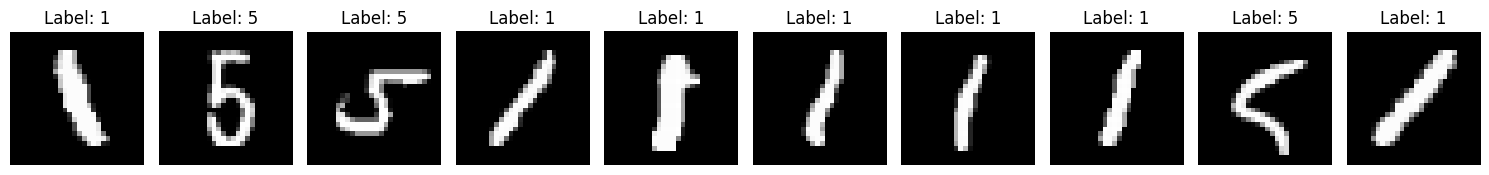

In [3]:
# just to visualize some of the data before we start training our model 
# let's see some examples of the digits we're working with
plt.figure(figsize=(15, 3))
# We'll pick random indices to show variety
num_examples = 10
random_indices = np.random.choice(X_filtered.shape[0], num_examples, replace=False)
    
for i, idx in enumerate(random_indices):
    plt.subplot(1, num_examples, i + 1)
        
    # Reshape the flat 784 array back to 28x28 for plotting
    image = X_filtered[idx].reshape(28, 28)
        
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {y_filtered[idx]}")
    plt.axis('off')
    
plt.tight_layout()
plt.show()

In [4]:
# explains why we use sigmoid function in the output layer since we have binary classification.
print(np.unique(y_train))

[0 1]


In [5]:
# Reshape for our neural network implementation
X_train = X_train.T
X_test = X_test.T
y_train = y_train.reshape(1, -1)
y_test = y_test.reshape(1, -1)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test data shape: X={X_test.shape}, y={y_test.shape}")

Training data shape: X=(784, 11352), y=(1, 11352)
Test data shape: X=(784, 2838), y=(1, 2838)


### Implementation From Scratch

In [6]:
def sigmoid(Z):
    # Clip Z to avoid overflow/underflow warnings
    Z = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z))

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return Z > 0

#binary cross-entropy loss function
def compute_loss(Y, A2):
    m = Y.shape[1]
    # Add a tiny epsilon to avoid log(0)
    epsilon = 1e-8
    loss = - (1/m) * np.sum(Y * np.log(A2 + epsilon) + (1 - Y) * np.log(1 - A2 + epsilon))
    return loss

In [7]:
def initialize_parameters(input_size, hidden_size, output_size):
    W1 = np.random.randn(hidden_size, input_size) * np.sqrt(2. / input_size)
    b1 = np.zeros((hidden_size, 1))
    W2 = np.random.randn(output_size, hidden_size) * np.sqrt(1. / hidden_size)
    b2 = np.zeros((output_size, 1))
    
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def forward_propagation(X, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

def backward_propagation(X, Y, cache, params):
    m = X.shape[1]
    W2 = params["W2"]
    A1, A2, Z1 = cache["A1"], cache["A2"], cache["Z1"]
    
    # Compute the gradients using the chain rule 
    # write them in terms of the variables and parameters
    
    # Output layer gradients
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    
    # Hidden layer gradients
    dZ1 = np.dot(W2.T, dZ2) * relu_derivative(Z1)
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

In [8]:
def train_gd(X, Y, epochs, learning_rate):
    params = initialize_parameters(784, 64, 1)
    loss_history = []
    
    for i in range(epochs):
        # 1. Forward Pass
        A2, cache = forward_propagation(X, params)
        
        # 2. Compute Loss
        loss = compute_loss(Y, A2)
        loss_history.append(loss)
        
        # 3. Backward Pass (on ENTIRE dataset)
        grads = backward_propagation(X, Y, cache, params)
        
        # 4. Update Weights
        params["W1"] -= learning_rate * grads["dW1"]
        params["b1"] -= learning_rate * grads["db1"]
        params["W2"] -= learning_rate * grads["dW2"]
        params["b2"] -= learning_rate * grads["db2"]
        
        if i % 10 == 0:
            print(f"GD - Epoch {i:3d} | Loss: {loss:.4f}")
            
    return params, loss_history

def train_sgd(X, Y, epochs, learning_rate, batch_size=128):
    params = initialize_parameters(784, 64, 1)
    loss_history = []
    m = X.shape[1]
    
    for i in range(epochs):
        # Shuffle data at the start of each epoch
        permutation = np.random.permutation(m)
        X_shuffled = X[:, permutation]
        Y_shuffled = Y[:, permutation]
        
        epoch_losses = []
        
        # Iterate over mini-batches
        for j in range(0, m, batch_size):
            X_batch = X_shuffled[:, j:j+batch_size]
            Y_batch = Y_shuffled[:, j:j+batch_size]
            
            # Forward, Loss, Backward (on BATCH)
            A2, cache = forward_propagation(X_batch, params)
            epoch_losses.append(compute_loss(Y_batch, A2))
            grads = backward_propagation(X_batch, Y_batch, cache, params)
            
            # Update Weights
            params["W1"] -= learning_rate * grads["dW1"]
            params["b1"] -= learning_rate * grads["db1"]
            params["W2"] -= learning_rate * grads["dW2"]
            params["b2"] -= learning_rate * grads["db2"]
            
        # Record average loss for the epoch
        avg_loss = np.mean(epoch_losses)
        loss_history.append(avg_loss)
        
        if i % 10 == 0:
             print(f"SGD - Epoch {i:3d} | Loss: {avg_loss:.4f}")
            
    return params, loss_history

--- Training with Gradient Descent ---
GD - Epoch   0 | Loss: 0.7252
GD - Epoch  10 | Loss: 0.2602
GD - Epoch  20 | Loss: 0.1401
GD - Epoch  30 | Loss: 0.0974
GD - Epoch  40 | Loss: 0.0766

--- Training with SGD (Batch Size = 128) ---
SGD - Epoch   0 | Loss: 0.1302
SGD - Epoch  10 | Loss: 0.0124
SGD - Epoch  20 | Loss: 0.0083
SGD - Epoch  30 | Loss: 0.0060
SGD - Epoch  40 | Loss: 0.0045


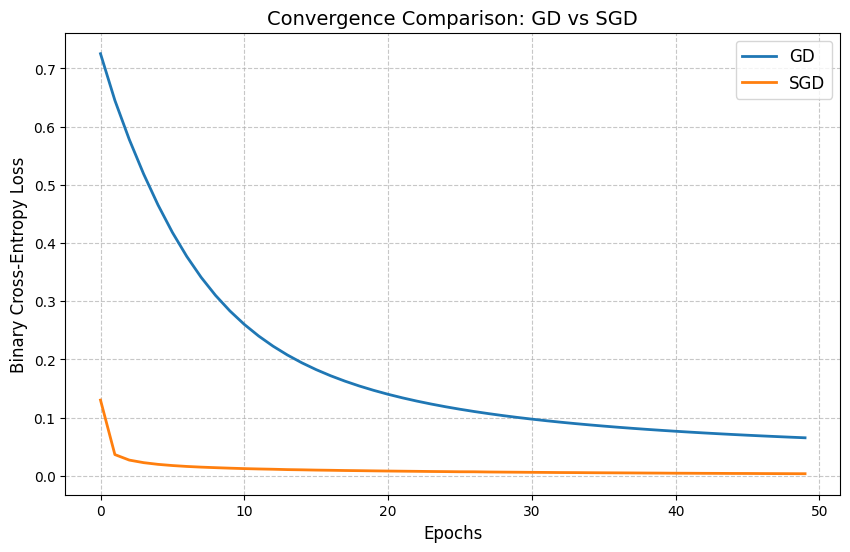


Final Test Accuracy (GD): 98.73%
Final Test Accuracy (SGD): 99.65%


In [12]:
# Hyperparameters - you can play around with these to see how they affect convergence!
epochs = 50
learning_rate = 0.1
batch_size = 128

print("--- Training with Gradient Descent ---")
params_gd, loss_gd = train_gd(X_train, y_train, epochs, learning_rate)

print(f"\n--- Training with SGD (Batch Size = {batch_size}) ---")
params_sgd, loss_sgd = train_sgd(X_train, y_train, epochs, learning_rate, batch_size=batch_size)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(loss_gd, label="GD", linewidth=2)
plt.plot(loss_sgd, label="SGD", linewidth=2)
plt.title("Convergence Comparison: GD vs SGD", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Quick evaluation function
def evaluate(X, Y, params):
    A2, _ = forward_propagation(X, params)
    predictions = (A2 > 0.5).astype(int)
    accuracy = np.mean(predictions == Y) * 100
    return accuracy

print(f"\nFinal Test Accuracy (GD): {evaluate(X_test, y_test, params_gd):.2f}%")
print(f"Final Test Accuracy (SGD): {evaluate(X_test, y_test, params_sgd):.2f}%")

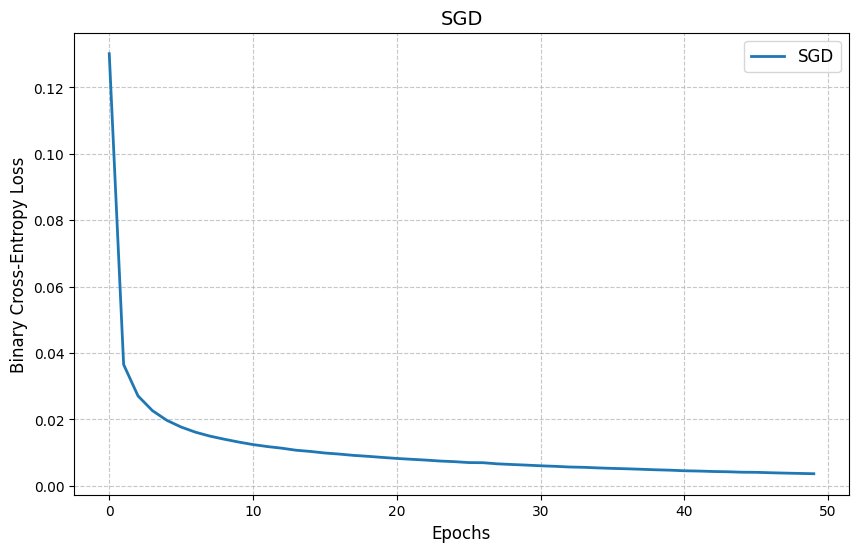

In [13]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(loss_sgd, label="SGD", linewidth=2)
plt.title("SGD", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Pytorch Implementation

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Convert our existing numpy arrays to PyTorch Tensors.
# Note: PyTorch expects tabular data in the shape (batch_size, features).
# Our scratch implementation used (features, batch_size), so we transpose (.T) them back.
X_train_tensor = torch.tensor(X_train.T, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.T, dtype=torch.float32) 
X_test_tensor = torch.tensor(X_test.T, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.T, dtype=torch.float32)

# Create DataLoaders to automatically handle mini-batching and shuffling
batch_size = 128

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

print(f"PyTorch Training Data Shape: {X_train_tensor.shape}")

PyTorch Training Data Shape: torch.Size([11352, 784])


In [15]:
# Define the exact same architecture: 784 -> 64 -> 1
model = nn.Sequential(
    nn.Linear(784, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

# Define Binary Cross Entropy Loss
criterion = nn.BCELoss()

# Pick an optimizer (Adam, SGD, etc.)
learning_rate_pytorch = 0.1
optimizer = optim.Adam(model.parameters(), lr=learning_rate_pytorch)

print(model)

Sequential(
  (0): Linear(in_features=784, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=1, bias=True)
  (3): Sigmoid()
)


In [16]:
epochs_pytorch = 50 
pytorch_loss_history = []

print("--- Training with PyTorch ---")

for epoch in range(epochs_pytorch):
    epoch_losses = []
    
    # Iterate through the batches provided by the DataLoader
    for X_batch, y_batch in train_loader:
        
        # 1. Forward pass
        predictions = model(X_batch)
        
        # 2. Calculate Loss
        loss = criterion(predictions, y_batch)
        epoch_losses.append(loss.item())
        
        # 3. Zero the gradients
        optimizer.zero_grad()
        
        # 4. Backward pass (Autograd does the math for us!)
        loss.backward()
        
        # 5. Update weights
        optimizer.step()
        
    # Record average loss for the epoch
    avg_loss = np.mean(epoch_losses)
    pytorch_loss_history.append(avg_loss)
    
    if epoch % 10 == 0 or epoch == epochs_pytorch - 1:
        print(f"PyTorch - Epoch {epoch:2d} | Loss: {avg_loss:.4f}")

--- Training with PyTorch ---
PyTorch - Epoch  0 | Loss: 0.1876
PyTorch - Epoch 10 | Loss: 0.0001
PyTorch - Epoch 20 | Loss: 0.0000
PyTorch - Epoch 30 | Loss: 0.0000
PyTorch - Epoch 40 | Loss: 0.0000
PyTorch - Epoch 49 | Loss: 0.0000



Final Test Accuracy (PyTorch + Adam): 99.75%


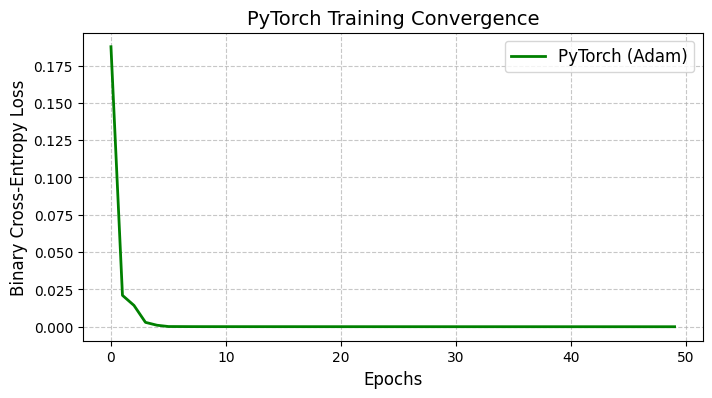

In [17]:
# Set the model to evaluation mode
model.eval()

# Turn off gradient tracking for evaluation
with torch.no_grad():
    # Get predictions for the whole test set
    test_predictions = model(X_test_tensor)
    
    # Convert probabilities to binary 0 or 1
    predicted_classes = (test_predictions > 0.5).float()
    
    # Calculate accuracy
    correct = (predicted_classes == y_test_tensor).sum().item()
    total = y_test_tensor.size(0)
    accuracy = (correct / total) * 100

print(f"\nFinal Test Accuracy (PyTorch + Adam): {accuracy:.2f}%")

# Plotting the PyTorch loss
plt.figure(figsize=(8, 4))
plt.plot(pytorch_loss_history, color='green', label="PyTorch (Adam)", linewidth=2)
plt.title("PyTorch Training Convergence", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()